In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

In [12]:
df = pd.read_csv("dataset_particulas_unificado_F.csv")
df.head()

,pt,eta,phi,particle_type,event_id
0,2.06272,-0.233066,-0.154099,electron,1203594102
1,2.65992,2.005970,-2.187040,electron,1203594102
2,27.85330,-1.332450,1.910920,tau,1203594102
3,1.58189,-1.451010,-0.961732,tau,1203594102
4,2.12971,-1.054230,-2.037100,tau,1203594102


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10769 entries, 0 to 10768
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pt             10769 non-null  float64
 1   eta            10769 non-null  float64
 2   phi            10769 non-null  float64
 3   particle_type  10769 non-null  object 
 4   event_id       10769 non-null  int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 420.8+ KB


In [14]:
# Features
X = df[['pt', 'eta', 'phi', 'event_id']]

# Target
y = df['particle_type']

# Entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [15]:

# Escalador
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Modelo
logreg = LogisticRegression(
    max_iter=2000,
    multi_class='multinomial',
    solver='lbfgs'
)

# Entrenamiento ÚNICO
logreg.fit(X_train_scaled, y_train)


C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'multinomial'


In [16]:
y_pred = logreg.predict(X_test_scaled)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

    electron       0.00      0.00      0.00        16
        muon       0.00      0.00      0.00        38
      photon       0.29      0.06      0.10        34
         tau       0.71      0.30      0.42      1130
       track       0.70      0.96      0.81      2013

    accuracy                           0.70      3231
   macro avg       0.34      0.26      0.27      3231
weighted avg       0.69      0.70      0.65      3231



C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

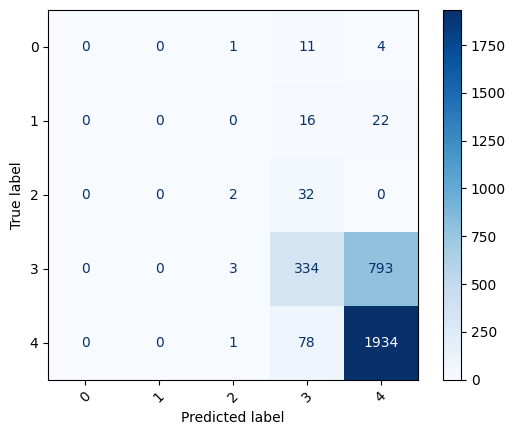

In [17]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.show()

C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


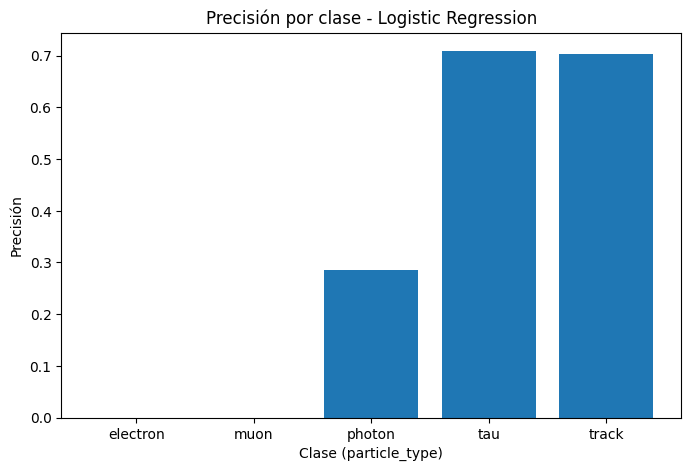

In [18]:
from sklearn.metrics import precision_score

# Obtener precisiones por clase
labels = sorted(y.unique())
precisiones = precision_score(y_test, y_pred, average=None, labels=labels)

# Graficar
plt.figure(figsize=(8,5))
plt.bar(labels, precisiones)
plt.xlabel("Clase (particle_type)")
plt.ylabel("Precisión")
plt.title("Precisión por clase - Logistic Regression")
plt.show()


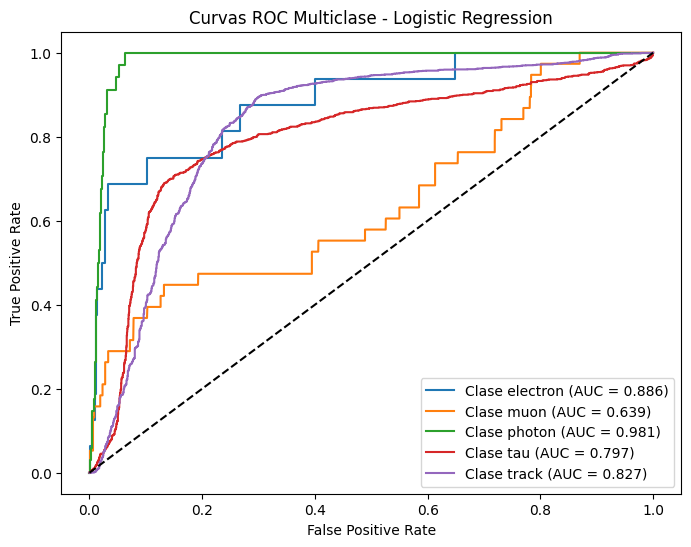

In [19]:
# Binarización de etiquetas
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = logreg.predict_proba(X_test_scaled)

plt.figure(figsize=(8,6))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Clase {cls} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC Multiclase - Logistic Regression")
plt.legend()
plt.show()

C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\l

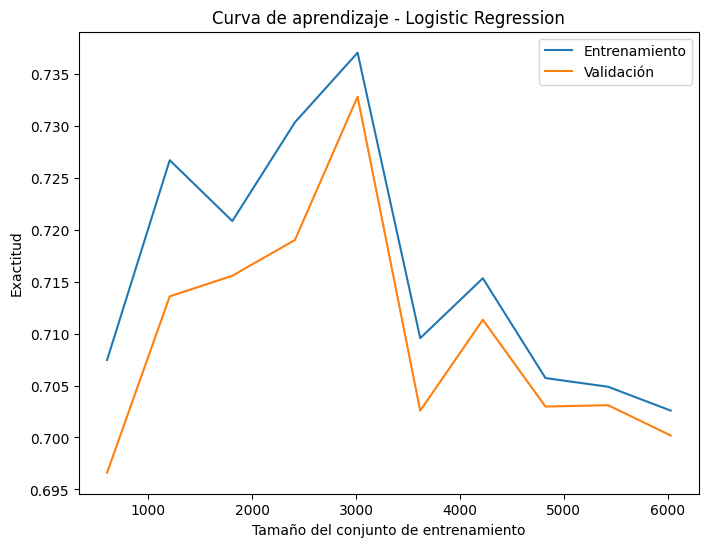

In [20]:
train_sizes, train_scores, test_scores = learning_curve(
    logreg,
    X_train_scaled,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label="Entrenamiento")
plt.plot(train_sizes, test_mean, label="Validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de aprendizaje - Logistic Regression")
plt.legend()
plt.show()


## SIN REPETIDOS

In [21]:
df = pd.read_csv("dataset_sin_repetidos.csv")
df.head()

,pt,eta,phi,particle_type,event_id
0,2.06272,-0.233066,-0.154099,electron,1203594102
1,2.65992,2.005970,-2.187040,electron,1203594102
2,27.85330,-1.332450,1.910920,tau,1203594102
3,1.58189,-1.451010,-0.961732,tau,1203594102
4,2.12971,-1.054230,-2.037100,tau,1203594102


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10708 entries, 0 to 10707
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pt             10708 non-null  float64
 1   eta            10708 non-null  float64
 2   phi            10708 non-null  float64
 3   particle_type  10708 non-null  object 
 4   event_id       10708 non-null  int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 418.4+ KB


In [23]:
# Features
X = df[['pt', 'eta', 'phi', 'event_id']]

# Target
y = df['particle_type']

# Entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [24]:
%%time
# Escalador
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Modelo
logreg = LogisticRegression(
    max_iter=2000,
    multi_class='multinomial',
    solver='lbfgs'
)

# Entrenamiento ÚNICO
logreg.fit(X_train_scaled, y_train)


CPU times: total: 15.6 ms
Wall time: 32.4 ms


C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'multinomial'


In [25]:
y_pred = logreg.predict(X_test_scaled)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

    electron       0.00      0.00      0.00        16
        muon       0.00      0.00      0.00        20
      photon       0.27      0.09      0.13        34
         tau       0.71      0.28      0.40      1130
       track       0.70      0.96      0.81      2013

    accuracy                           0.70      3213
   macro avg       0.34      0.27      0.27      3213
weighted avg       0.69      0.70      0.65      3213



C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

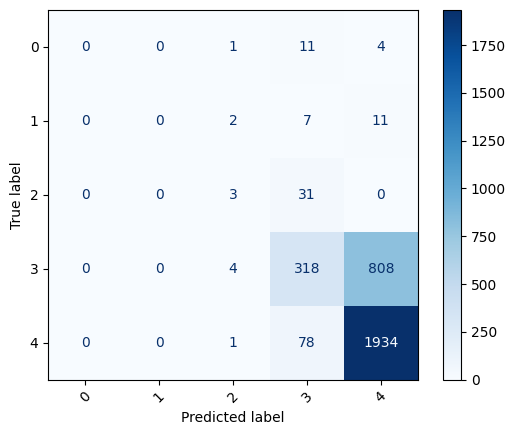

In [26]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.show()

C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


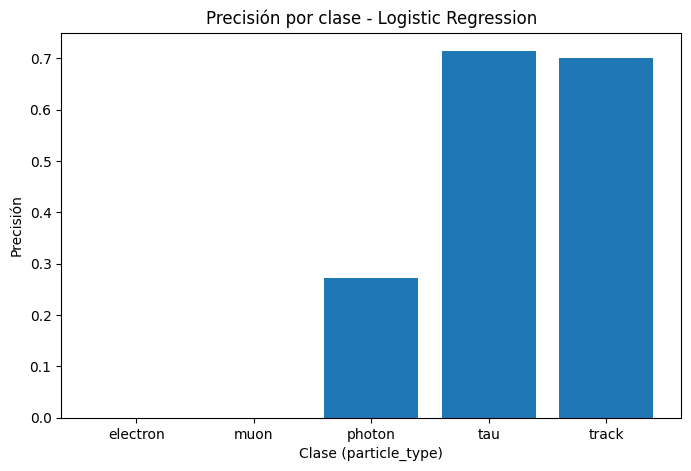

In [27]:
from sklearn.metrics import precision_score

# Obtener precisiones por clase
labels = sorted(y.unique())
precisiones = precision_score(y_test, y_pred, average=None, labels=labels)

# Graficar
plt.figure(figsize=(8,5))
plt.bar(labels, precisiones)
plt.xlabel("Clase (particle_type)")
plt.ylabel("Precisión")
plt.title("Precisión por clase - Logistic Regression")
plt.show()


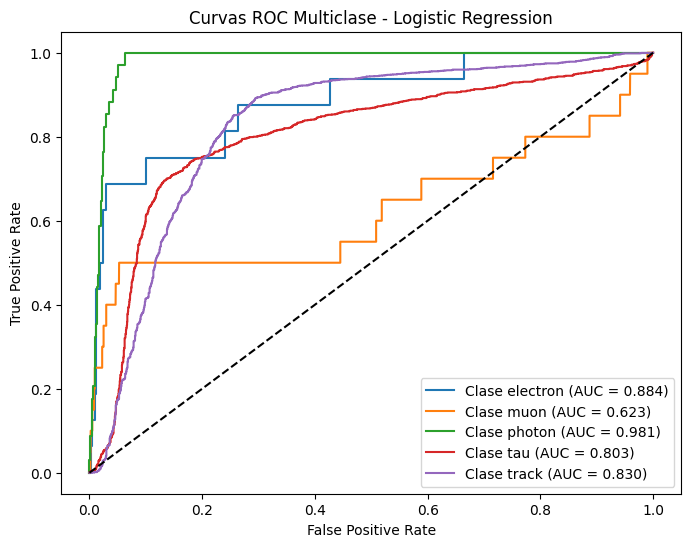

In [28]:
# Binarización de etiquetas
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = logreg.predict_proba(X_test_scaled)

plt.figure(figsize=(8,6))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Clase {cls} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC Multiclase - Logistic Regression")
plt.legend()
plt.show()

C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\l

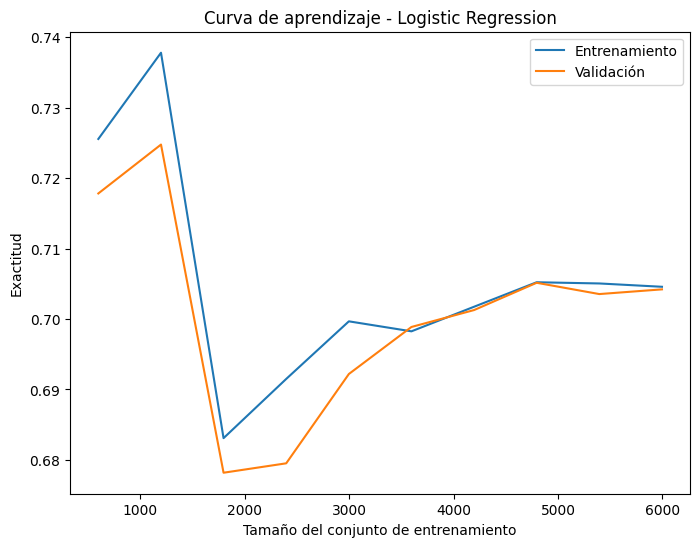

In [29]:
train_sizes, train_scores, test_scores = learning_curve(
    logreg,
    X_train_scaled,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label="Entrenamiento")
plt.plot(train_sizes, test_mean, label="Validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de aprendizaje - Logistic Regression")
plt.legend()
plt.show()


NO C

In [41]:
df = pd.read_csv("dataset_ampliado.csv")
df.head()

,pt,eta,phi,charge,pos_x,pos_y,pos_z,dir_x,dir_y,dir_z,particle_type,event_id
0,1.37519,-1.632300,2.02698,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,muon,652620608
1,1.61969,-1.470510,-2.37353,1.0,NaN,NaN,NaN,NaN,NaN,NaN,muon,652620608
2,35.55600,0.005784,1.83400,NaN,0.000726,0.000609,-0.047592,NaN,NaN,NaN,photon,652620608
3,30.93680,1.948290,-1.74553,NaN,0.000726,0.000609,-0.047592,NaN,NaN,NaN,photon,652620608
4,1.07084,-0.797238,3.12657,-1.0,0.000716,0.000532,-0.087838,-0.748987,0.011251,-0.66249,track,652620608


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10769 entries, 0 to 10768
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pt             10769 non-null  float64
 1   eta            10769 non-null  float64
 2   phi            10769 non-null  float64
 3   charge         10657 non-null  float64
 4   pos_x          6937 non-null   float64
 5   pos_y          6937 non-null   float64
 6   pos_z          6937 non-null   float64
 7   dir_x          6764 non-null   float64
 8   dir_y          6764 non-null   float64
 9   dir_z          6764 non-null   float64
 10  particle_type  10769 non-null  object 
 11  event_id       10769 non-null  int64  
dtypes: float64(10), int64(1), object(1)
memory usage: 1009.7+ KB


In [45]:
# Reemplazar cadenas vacías por NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

# Convertir columnas numéricas
numeric_cols = ['pt','eta','phi','charge',
                'pos_x','pos_y','pos_z',
                'dir_x','dir_y','dir_z',
                'event_id']

df[numeric_cols] = df[numeric_cols].astype(float)


In [50]:
X = df[numeric_cols]               # Todas las columnas numéricas
y = df['particle_type']            # La etiqueta

In [51]:
df.isna().sum()


pt               0
eta              0
phi              0
charge           0
pos_x            0
pos_y            0
pos_z            0
dir_x            0
dir_y            0
dir_z            0
particle_type    0
event_id         0
dtype: int64

In [48]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

# Solo imputamos las columnas numéricas
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [53]:
%%time
# Escalador
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Modelo
logreg = LogisticRegression(
    max_iter=2000,
    multi_class='multinomial',
    solver='lbfgs'
)

# Entrenamiento ÚNICO
logreg.fit(X_train_scaled, y_train)

CPU times: total: 46.9 ms
Wall time: 39.1 ms


C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'multinomial'
